<a href="https://colab.research.google.com/github/M777WAEL/Deep-Learning/blob/main/notebooks/Brain_MRI_SVM_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("GPU Available:",
      tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [ ]:
train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

print(train_dir)
print(test_dir)

/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Testing


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(4, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30
)

Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 83s 558ms/step - accuracy: 0.9235 - loss: 0.2060 - val_accuracy: 0.9190 - val_loss: 0.2297
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 542ms/step - accuracy: 0.9187 - loss: 0.2107 - val_accuracy: 0.9238 - val_loss: 0.2174
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 549ms/step - accuracy: 0.9315 - loss: 0.1927 - val_accuracy: 0.9155 - val_loss: 0.2230
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 545ms/step - accuracy: 0.9330 - loss: 0.1818 - val_accuracy: 0.9262 - val_loss: 0.2237
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 542ms/step - accuracy: 0.9315 - loss: 0.1887 - val_accuracy: 0.9167 - val_loss: 0.2237
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 84s 561ms/step - accuracy: 0.9292 - loss: 0.1845 - val_accuracy: 0.9321 - val_loss: 0.2039
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 549ms/step - accuracy: 0.9334 - loss: 0.1823 - val_accuracy: 0.9262 - val_loss: 0.2086
Epoch 8/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 553ms/step - accuracy: 0.9395 - loss: 0

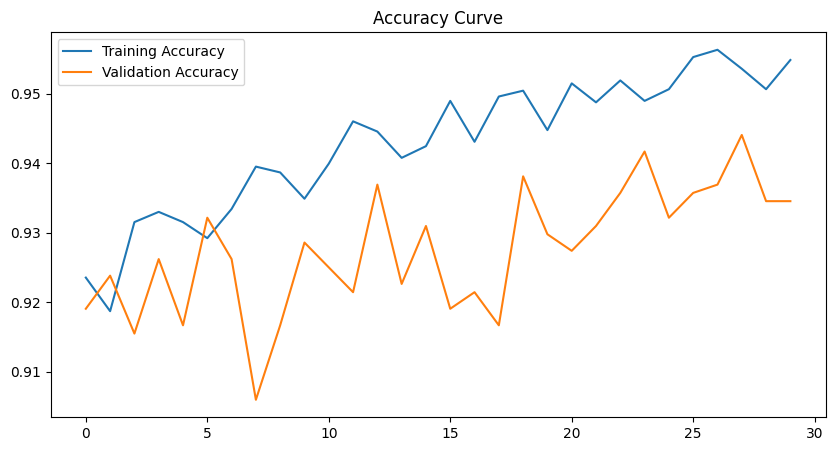

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title('Accuracy Curve')

plt.show()

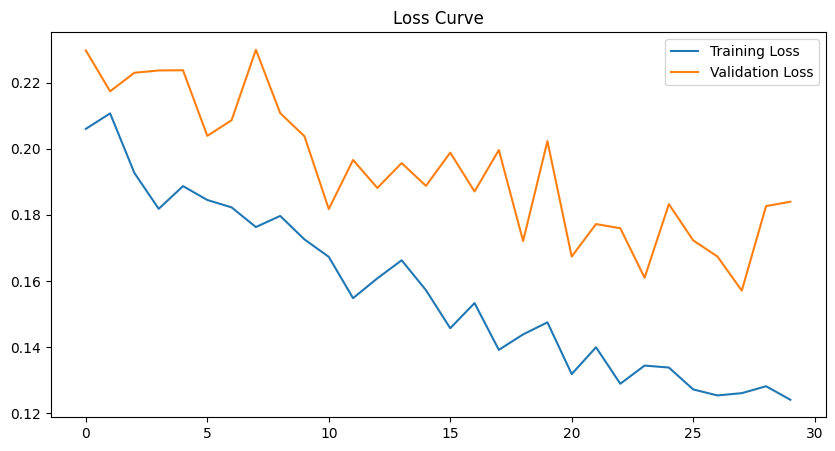

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title('Loss Curve')

plt.show()

In [ ]:
pred_probs = model.predict(test_generator)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

print(classification_report(
    true_classes,
    pred_classes
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step
              precision    recall  f1-score   support

           0       0.96      0.74      0.84       400
           1       0.82      0.91      0.86       400
           2       0.93      1.00      0.97       400
           3       0.94      0.98      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



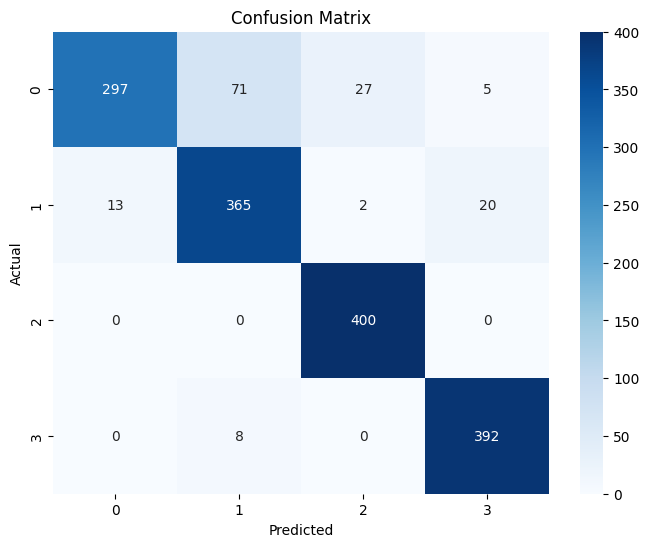

In [ ]:
cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
# ============================================
# CREATE PDF REPORT FOR END-TO-END RESNET50
# ============================================

!pip install -q reportlab

# ============================================
# Imports
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    Table,
    TableStyle
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter

# ============================================
# Predictions
# ============================================

pred_probs = model.predict(test_generator)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

true_classes = test_generator.classes

# ============================================
# Metrics
# ============================================

accuracy = accuracy_score(
    true_classes,
    pred_classes
)

report = classification_report(
    true_classes,
    pred_classes,
    output_dict=True
)

report_text = classification_report(
    true_classes,
    pred_classes
)

print(report_text)

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("endtoend_confusion_matrix.png")

plt.close()

# ============================================
# Accuracy Curve
# ============================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title('Accuracy Curve')

plt.savefig("accuracy_curve.png")

plt.close()

# ============================================
# Loss Curve
# ============================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title('Loss Curve')

plt.savefig("loss_curve.png")

plt.close()

# ============================================
# Create PDF
# ============================================

doc = SimpleDocTemplate(
    "EndToEnd_ResNet50_Report.pdf",
    pagesize=letter
)

styles = getSampleStyleSheet()

elements = []

# ============================================
# Title
# ============================================

title = Paragraph(
    "Brain MRI End-to-End ResNet50 Report",
    styles['Title']
)

elements.append(title)

elements.append(Spacer(1,20))

# ============================================
# Accuracy
# ============================================

acc_text = Paragraph(
    f"<b>Model Accuracy:</b> {accuracy:.4f}",
    styles['BodyText']
)

elements.append(acc_text)

elements.append(Spacer(1,20))

# ============================================
# Classification Report Table
# ============================================

table_data = [
    ['Class', 'Precision', 'Recall', 'F1-Score']
]

for key in ['0', '1', '2', '3']:

    table_data.append([
        key,
        f"{report[key]['precision']:.2f}",
        f"{report[key]['recall']:.2f}",
        f"{report[key]['f1-score']:.2f}"
    ])

table = Table(table_data)

table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR',(0,0),(-1,0),colors.whitesmoke),

    ('ALIGN',(0,0),(-1,-1),'CENTER'),

    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),

    ('BOTTOMPADDING', (0,0), (-1,0), 12),

    ('BACKGROUND',(0,1),(-1,-1),colors.beige),

    ('GRID', (0,0), (-1,-1), 1, colors.black)
]))

elements.append(table)

elements.append(Spacer(1,30))

# ============================================
# Confusion Matrix
# ============================================

elements.append(
    Paragraph(
        "Confusion Matrix",
        styles['Heading2']
    )
)

elements.append(
    Image(
        "endtoend_confusion_matrix.png",
        width=400,
        height=300
    )
)

elements.append(Spacer(1,20))

# ============================================
# Accuracy Curve
# ============================================

elements.append(
    Paragraph(
        "Accuracy Curve",
        styles['Heading2']
    )
)

elements.append(
    Image(
        "accuracy_curve.png",
        width=400,
        height=250
    )
)

elements.append(Spacer(1,20))

# ============================================
# Loss Curve
# ============================================

elements.append(
    Paragraph(
        "Loss Curve",
        styles['Heading2']
    )
)

elements.append(
    Image(
        "loss_curve.png",
        width=400,
        height=250
    )
)

# ============================================
# Build PDF
# ============================================

doc.build(elements)

print("PDF Report Created Successfully")

# ============================================
# Download PDF
# ============================================

from google.colab import files

files.download("EndToEnd_ResNet50_Report.pdf")

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step
              precision    recall  f1-score   support

           0       0.96      0.74      0.84       400
           1       0.82      0.91      0.86       400
           2       0.93      1.00      0.97       400
           3       0.94      0.98      0.96       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600

PDF Report Created Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>